# Notebook 03 · Análisis del Funnel de Conversión
> **Nexus RecSys** — Sistema de Recomendación · Retailrocket Dataset

---

| Campo | Detalle |
|---|---|
| **Fuente** | `data/interim/cp01_events_clean.parquet` |
| **Checkpoint de salida** | `data/interim/cp03_funnel_metrics.parquet` |
| **Objetivo** | Cuantificar el embudo `view → addtocart → transaction`, detectar anomalías estructurales, medir la velocidad de decisión del usuario y construir el DataFrame de métricas de comportamiento por visitante |

---

### Contexto de negocio

El funnel de conversión es la **pieza analítica central** del proyecto: determina qué tan eficientemente los visitantes avanzan desde la exploración del catálogo hasta la compra efectiva.

Las **tasas de conversión** y los **tiempos entre etapas** son inputs directos para:
- La función de pérdida del modelo (señales implícitas ponderadas).
- La estrategia de ranking (valorar `addtocart` como señal de intención fuerte).
- La segmentación de usuarios (cold-start vs. compradores activos).

### Mapa del notebook

| Paso | Descripción |
|---|---|
| **1** · Funnel global | Usuarios únicos por etapa, tasas de conversión agregadas |
| **2** · Funnel (visitor × item) | Análisis por par — qué ítems vistos terminaron en carrito o compra |
| **3** · Anomalías | Cuantificación de eventos fuera de orden: transacciones sin view ni carrito previo |
| **4** · Métricas por usuario | Construcción del DataFrame `funnel_metrics` serializado como checkpoint |


In [11]:
# ─── SETUP OBLIGATORIO ───────────────────────────────────────────────────────
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(message)s')
logger = logging.getLogger(__name__)

BASE_DIR       = Path('..')
CHECKPOINT_IN  = BASE_DIR / 'data' / 'interim' / 'cp01_events_clean.parquet'
CHECKPOINT_OUT = BASE_DIR / 'data' / 'interim' / 'cp03_funnel_metrics.parquet'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Cargar checkpoint
df = pd.read_parquet(CHECKPOINT_IN)
logger.info("Checkpoint cargado: shape=%s", df.shape)
print(f"Shape: {df.shape}")
display(df.head(3))


2026-03-12 00:22:17,354 — Checkpoint cargado: shape=(2755641, 9)


Shape: (2755641, 9)


,timestamp,visitorid,event,itemid,transactionid,hour,day_of_week,date,week_number
0,2015-06-02 05:02:12.117000+00:00,257597,view,355908,NaN,5,1,2015-06-02,23
1,2015-06-02 05:50:14.164000+00:00,992329,view,248676,NaN,5,1,2015-06-02,23
2,2015-06-02 05:13:19.827000+00:00,111016,view,318965,NaN,5,1,2015-06-02,23


---
## Paso 1 · Funnel Global de Conversión

Usuarios únicos que alcanzaron cada etapa del embudo y tasas de conversión entre etapas consecutivas. El análisis se hace a nivel de **visitante** (no de evento), reflejando la proporción real de personas que avanzan en el proceso de compra. Esta vista macro define el rendimiento base del sitio e-commerce y establece los límites superiores de lo que el sistema de recomendación puede mejorar.


2026-03-12 00:13:16,493 — users_view=1404179 | users_addtocart=37722 | users_transaction=11719
2026-03-12 00:13:16,494 — CR view→cart=0.0269 | CR cart→buy=0.3107 | CR global=0.0083


── Funnel Global ──


,etapa,usuarios,cr_vs_view,cr_vs_prev,cr_vs_view_pct,cr_vs_prev_pct
0,view,1404179,1.000000,1.000000,100.00,100.00
1,addtocart,37722,0.026864,0.026864,2.69,2.69
2,transaction,11719,0.008346,0.310668,0.83,31.07


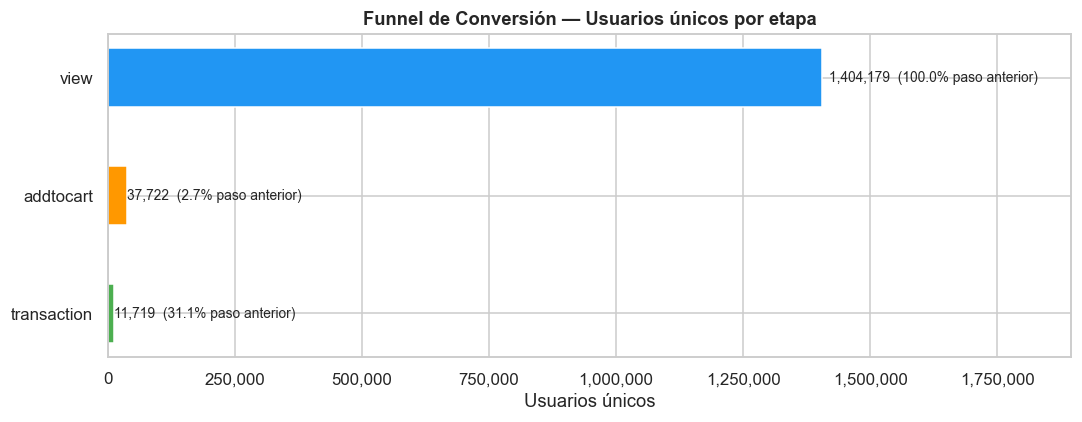


  CR view → addtocart  : 2.686%
  CR addtocart → transaction : 31.067%
  CR global (view → buy): 0.835%


In [2]:
# ─── 1. FUNNEL GLOBAL ────────────────────────────────────────────────────────

# Usuarios únicos por etapa
users_view        = df[df['event'] == 'view']['visitorid'].nunique()
users_addtocart   = df[df['event'] == 'addtocart']['visitorid'].nunique()
users_transaction = df[df['event'] == 'transaction']['visitorid'].nunique()

# Tasas de conversión
cr_view_to_cart  = users_addtocart   / users_view
cr_cart_to_buy   = users_transaction / users_addtocart
cr_global        = users_transaction / users_view

logger.info("users_view=%d | users_addtocart=%d | users_transaction=%d",
            users_view, users_addtocart, users_transaction)
logger.info("CR view→cart=%.4f | CR cart→buy=%.4f | CR global=%.4f",
            cr_view_to_cart, cr_cart_to_buy, cr_global)

# Tabla resumen
funnel_summary = pd.DataFrame({
    'etapa'     : ['view', 'addtocart', 'transaction'],
    'usuarios'  : [users_view, users_addtocart, users_transaction],
    'cr_vs_view': [1.0, cr_view_to_cart, cr_global],
    'cr_vs_prev': [1.0, cr_view_to_cart, cr_cart_to_buy],
})
funnel_summary['cr_vs_view_pct'] = (funnel_summary['cr_vs_view'] * 100).round(2)
funnel_summary['cr_vs_prev_pct'] = (funnel_summary['cr_vs_prev'] * 100).round(2)
print("── Funnel Global ──")
display(funnel_summary)

# ── Funnel chart ──────────────────────────────────────────────────────────────
etapas  = funnel_summary['etapa'].tolist()
valores = funnel_summary['usuarios'].tolist()
colores = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(etapas[::-1], valores[::-1], color=colores[::-1], height=0.5)

for bar, val, cr_p in zip(bars, valores[::-1], funnel_summary['cr_vs_prev_pct'].tolist()[::-1]):
    ax.text(bar.get_width() + bar.get_width() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({cr_p:.1f}% paso anterior)',
            va='center', fontsize=9)

ax.set_xlabel('Usuarios únicos')
ax.set_title('Funnel de Conversión — Usuarios únicos por etapa', fontsize=12, fontweight='bold')
ax.set_xlim(0, valores[0] * 1.35)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"\n  CR view → addtocart  : {cr_view_to_cart*100:.3f}%")
print(f"  CR addtocart → transaction : {cr_cart_to_buy*100:.3f}%")
print(f"  CR global (view → buy): {cr_global*100:.3f}%")


---
## Paso 2 · Funnel a Nivel (visitorid, itemid)

El funnel global agrega a nivel de usuario. En este paso descendemos a la granularidad de **par (visitante, ítem)**: ¿qué proporción de los ítems vistos terminaron en carrito o en compra? Este nivel de análisis es el más relevante para el modelo de recomendación, ya que opera exactamente en esta granularidad.

Adicionalmente se calcula el **tiempo entre etapas** (en horas) para cuantificar la velocidad de decisión del usuario, un indicador de la urgencia de compra.

| Métrica | Interpretación |
|---|---|
| Pares view → addtocart | Ítems vistos que generaron intención activa de compra |
| Pares addtocart → transaction | De los ítems en carrito, fracción que llegó a compra efectiva |
| Tiempo view → cart (mediana) | Velocidad de formación de intención de compra |
| Tiempo cart → buy (mediana) | Velocidad de cierre / decisión final |


2026-03-12 00:13:23,077 — Pivot pairs shape: (2145179, 5)


── Funnel por par (visitor, item) ──
  Pares con view              :  2,132,127
  Pares view + addtocart      :     49,500  (2.322%)
  Pares view + cart + tx      :     17,353  (0.814%)
  Pares cart + tx (CR cart→buy):     19,045  (30.705%)

  Tiempo view → addtocart  (n=45,395)
    p25: 0.01 h
    p50: 0.02 h
    p75: 0.11 h
    p95: 31.51 h

  Tiempo addtocart → transaction  (n=18,942)
    p25: 0.04 h
    p50: 0.08 h
    p75: 0.21 h
    p95: 5.76 h


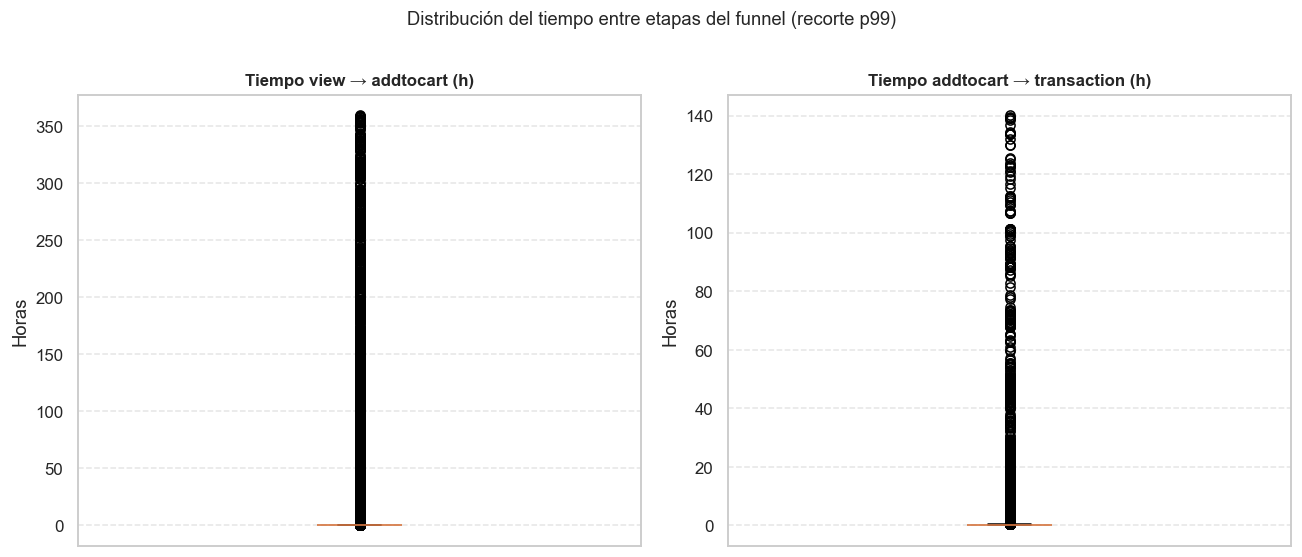

In [3]:
# ─── 2. FUNNEL A NIVEL (visitorid, itemid) ──────────────────────────────────

# Timestamp mínimo por (visitor, item, event)
min_ts = (df.groupby(['visitorid', 'itemid', 'event'])['timestamp']
            .min()
            .reset_index()
            .rename(columns={'timestamp': 'ts_first'}))

pivot = min_ts.pivot_table(
    index=['visitorid', 'itemid'],
    columns='event',
    values='ts_first'
).reset_index()
pivot.columns.name = None

# Asegurar que existan las columnas aunque no haya datos
for col in ['view', 'addtocart', 'transaction']:
    if col not in pivot.columns:
        pivot[col] = pd.NaT

logger.info("Pivot pairs shape: %s", pivot.shape)

# Conteo de pares
pairs_view         = pivot['view'].notna().sum()
pairs_vc           = (pivot['view'].notna() & pivot['addtocart'].notna()).sum()
pairs_vct          = (pivot['view'].notna() & pivot['addtocart'].notna()
                      & pivot['transaction'].notna()).sum()
pairs_ct           = (pivot['addtocart'].notna() & pivot['transaction'].notna()).sum()

cr_pairs_vc  = pairs_vc  / pairs_view
cr_pairs_vct = pairs_vct / pairs_view
cr_pairs_ct  = pairs_ct  / pivot['addtocart'].notna().sum()

print("── Funnel por par (visitor, item) ──")
print(f"  Pares con view              : {pairs_view:>10,}")
print(f"  Pares view + addtocart      : {pairs_vc:>10,}  ({cr_pairs_vc*100:.3f}%)")
print(f"  Pares view + cart + tx      : {pairs_vct:>10,}  ({cr_pairs_vct*100:.3f}%)")
print(f"  Pares cart + tx (CR cart→buy): {pairs_ct:>10,}  ({cr_pairs_ct*100:.3f}%)")

# Tiempo entre etapas (horas)
pivot['delta_view_cart_h'] = (
    (pivot['addtocart'] - pivot['view'])
    .dt.total_seconds() / 3600
)
pivot['delta_cart_buy_h'] = (
    (pivot['transaction'] - pivot['addtocart'])
    .dt.total_seconds() / 3600
)

def resumen_tiempo(serie, nombre):
    s = serie.dropna()
    s = s[s >= 0]   # descartar eventos fuera de orden
    print(f"\n  {nombre}  (n={len(s):,})")
    for q, lbl in zip([0.25, 0.50, 0.75, 0.95], ['p25', 'p50', 'p75', 'p95']):
        print(f"    {lbl}: {s.quantile(q):.2f} h")

resumen_tiempo(pivot['delta_view_cart_h'], 'Tiempo view → addtocart')
resumen_tiempo(pivot['delta_cart_buy_h'],  'Tiempo addtocart → transaction')

# Boxplot comparativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, titulo, color in zip(
    axes,
    ['delta_view_cart_h', 'delta_cart_buy_h'],
    ['view → addtocart', 'addtocart → transaction'],
    ['#2196F3', '#FF9800']
):
    datos = pivot[col].dropna()
    datos = datos[(datos >= 0) & (datos <= datos.quantile(0.99))]  # recorte p99
    ax.boxplot(datos, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5))
    ax.set_title(f'Tiempo {titulo} (h)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Horas')
    ax.set_xticks([])
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.suptitle('Distribución del tiempo entre etapas del funnel (recorte p99)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## Paso 3 · Anomalías del Funnel

Un funnel bien formado debería ser estrictamente ordenado: **view → addtocart → transaction**.  
Sin embargo, el dataset contiene casos donde:

- Una transacción ocurre sin que exista un `view` previo para ese ítem.
- Un `addtocart` ocurre sin `view` previo.
- Una transacción ocurre sin `addtocart` previo.

Estas anomalías pueden deberse a sesiones perdidas, registros fuera de contexto, o comportamiento real (ej. compra directa desde búsqueda, link externo).  
**Decisión de negocio**: se documentan, se cuantifican, pero **no se eliminan** — se retienen con una flag para uso posterior en modelos.


2026-03-12 00:13:27,716 — Anomalías: tx_sin_view=2219 (10.43%) | tx_sin_cart=2225 (10.46%) | cart_sin_view=12525 (20.19%)


── Anomalías del funnel ──
  Total pares con transaction          :   21,270
  Transactions sin view previo         :    2,219  (10.43%)
  Transactions sin addtocart previo    :    2,225  (10.46%)
  Addtocart sin view previo            :   12,525  (20.19%)


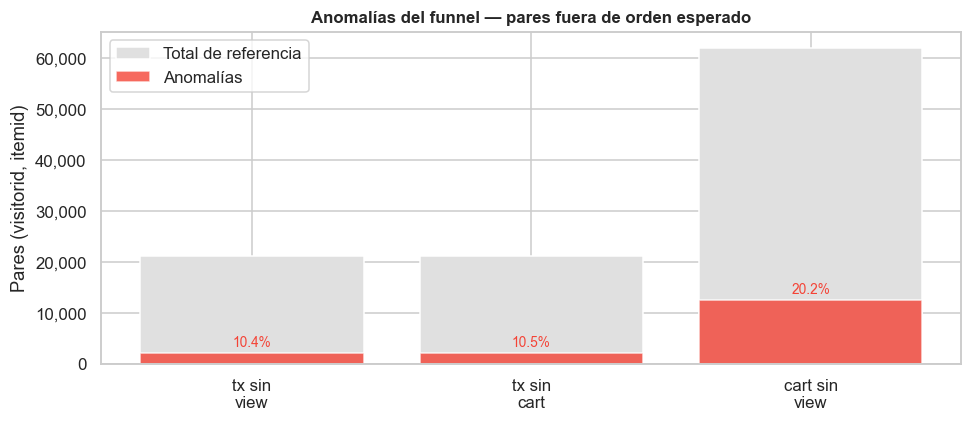


  Decisión: se conservan todos los registros.
  Se añadirá flag 'funnel_anomaly' en el DataFrame de métricas (Paso 5).


In [4]:
# ─── 3. ANOMALÍAS DEL FUNNEL ─────────────────────────────────────────────────

total_tx   = (pivot['transaction'].notna()).sum()
total_cart = (pivot['addtocart'].notna()).sum()

# Transacciones sin view previo
tx_sin_view = (pivot['transaction'].notna() & pivot['view'].isna()).sum()
# Transacciones sin addtocart previo
tx_sin_cart = (pivot['transaction'].notna() & pivot['addtocart'].isna()).sum()
# Addtocart sin view previo
cart_sin_view = (pivot['addtocart'].notna() & pivot['view'].isna()).sum()

pct_tx_sin_view  = tx_sin_view  / total_tx  * 100
pct_tx_sin_cart  = tx_sin_cart  / total_tx  * 100
pct_cart_sin_view= cart_sin_view/ total_cart * 100

print("── Anomalías del funnel ──")
print(f"  Total pares con transaction          : {total_tx:>8,}")
print(f"  Transactions sin view previo         : {tx_sin_view:>8,}  ({pct_tx_sin_view:.2f}%)")
print(f"  Transactions sin addtocart previo    : {tx_sin_cart:>8,}  ({pct_tx_sin_cart:.2f}%)")
print(f"  Addtocart sin view previo            : {cart_sin_view:>8,}  ({pct_cart_sin_view:.2f}%)")

logger.info("Anomalías: tx_sin_view=%d (%.2f%%) | tx_sin_cart=%d (%.2f%%) | "
            "cart_sin_view=%d (%.2f%%)",
            tx_sin_view, pct_tx_sin_view,
            tx_sin_cart, pct_tx_sin_cart,
            cart_sin_view, pct_cart_sin_view)

# Visualización: barras de anomalías vs total
anomalias = {
    'tx sin\nview': (tx_sin_view, total_tx),
    'tx sin\ncart' : (tx_sin_cart, total_tx),
    'cart sin\nview': (cart_sin_view, total_cart),
}
fig, ax = plt.subplots(figsize=(9, 4))
labels   = list(anomalias.keys())
counts   = [v[0] for v in anomalias.values()]
totals   = [v[1] for v in anomalias.values()]
pcts     = [c / t * 100 for c, t in zip(counts, totals)]

bars_bg  = ax.bar(labels, totals,  color='#e0e0e0', label='Total de referencia')
bars_anom = ax.bar(labels, counts, color='#F44336', alpha=0.8, label='Anomalías')

for bar, pct in zip(bars_anom, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(totals) * 0.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color='#F44336')

ax.set_ylabel('Pares (visitorid, itemid)')
ax.set_title('Anomalías del funnel — pares fuera de orden esperado',
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n  Decisión: se conservan todos los registros.")
print("  Se añadirá flag 'funnel_anomaly' en el DataFrame de métricas (Paso 5).")


## Paso 4 · Retención de Usuarios

¿Cuántos días estuvo activo cada usuario durante el período de observación?  
Clasificamos a los usuarios en cuatro segmentos según su duración de actividad:

| Segmento | Criterio | Estrategia sugerida |
|---|---|---|
| `one_time` | active_days = 1 | Retención agresiva — reactivar con recomendaciones |
| `short` | 2–7 días | Nurturing — personalización temprana |
| `medium` | 8–30 días | Fidelización — cross-sell / up-sell |
| `long` | > 30 días | Alta fidelidad — programa de referidos |

El período total de observación es de **137 días** (2015-05-03 → 2015-09-18).


2026-03-12 00:15:48,692 — Segmentos de retención: {'one_time': 1263811, 'short': 60462, 'medium': 42824, 'long': 40483}


── Distribución de segmentos ──
  one_time  : 1,263,811  (89.8%)
  short     :   60,462  (4.3%)
  medium    :   42,824  (3.0%)
  long      :   40,483  (2.9%)

  active_days — mediana: 1 | p75: 1 | p95: 11


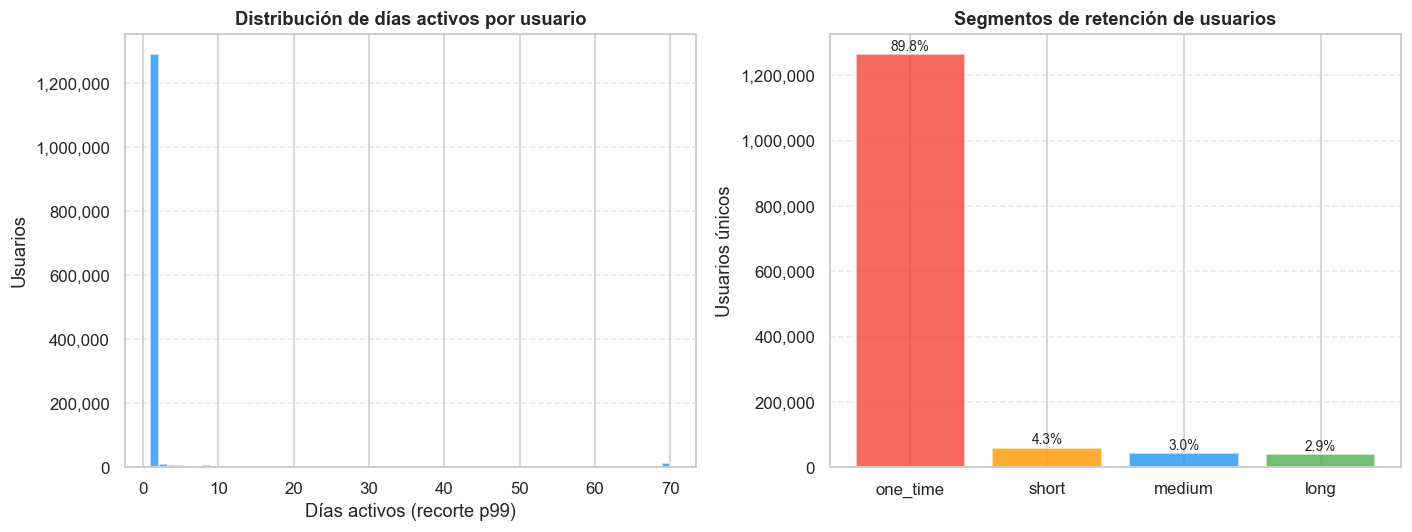

In [5]:
# ─── 4. RETENCIÓN DE USUARIOS ────────────────────────────────────────────────

retention = (
    df.groupby('visitorid')['date']
      .agg(first_event='min', last_event='max')
      .reset_index()
)
retention['first_event'] = pd.to_datetime(retention['first_event'])
retention['last_event']  = pd.to_datetime(retention['last_event'])
retention['active_days'] = (
    (retention['last_event'] - retention['first_event']).dt.days + 1
)

def segmentar(d):
    if d == 1:   return 'one_time'
    if d <= 7:   return 'short'
    if d <= 30:  return 'medium'
    return 'long'

retention['user_segment'] = retention['active_days'].apply(segmentar)

seg_counts = retention['user_segment'].value_counts()
seg_order  = ['one_time', 'short', 'medium', 'long']
seg_counts = seg_counts.reindex(seg_order, fill_value=0)

logger.info("Segmentos de retención: %s", seg_counts.to_dict())

print("── Distribución de segmentos ──")
for seg, cnt in seg_counts.items():
    pct = cnt / len(retention) * 100
    print(f"  {seg:<10}: {cnt:>8,}  ({pct:.1f}%)")

# Estadísticas de active_days
q_vals = retention['active_days'].quantile([0.25, 0.50, 0.75, 0.95])
print(f"\n  active_days — mediana: {q_vals[0.50]:.0f} | "
      f"p75: {q_vals[0.75]:.0f} | p95: {q_vals[0.95]:.0f}")

# Histograma + distribución de segmentos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de active_days (cap en p99)
cap = int(retention['active_days'].quantile(0.99))
axes[0].hist(retention['active_days'].clip(upper=cap), bins=60,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Días activos (recorte p99)')
axes[0].set_ylabel('Usuarios')
axes[0].set_title('Distribución de días activos por usuario', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Barras de segmentos
colores_seg = {'one_time': '#F44336', 'short': '#FF9800',
               'medium': '#2196F3', 'long': '#4CAF50'}
colores_list = [colores_seg[s] for s in seg_order]
axes[1].bar(seg_order, seg_counts.values, color=colores_list, alpha=0.8)
for i, (seg, cnt) in enumerate(zip(seg_order, seg_counts.values)):
    pct = cnt / len(retention) * 100
    axes[1].text(i, cnt + len(retention) * 0.002,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Usuarios únicos')
axes[1].set_title('Segmentos de retención de usuarios', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## Paso 5 · DataFrame de Métricas por Usuario

Consolidamos todas las señales calculadas en los pasos anteriores en un único DataFrame por usuario: **`user_funnel_metrics`**.  
Este será el artefacto de entrada para los módulos de feature engineering y modelado.

| Columna | Tipo | Descripción |
|---|---|---|
| `visitorid` | int32 | Identificador único del visitante |
| `n_views` | int32 | Número total de eventos view |
| `n_addtocarts` | int32 | Número total de eventos addtocart |
| `n_transactions` | int32 | Número total de eventos transaction |
| `cr_user` | float32 | Tasa de conversión individual (transacciones / vistas) |
| `active_days` | int32 | Días entre primera y última interacción (+1) |
| `first_event` | datetime | Fecha del primer evento |
| `last_event` | datetime | Fecha del último evento |
| `user_segment` | category | one_time / short / medium / long |
| `funnel_anomaly` | bool | True si tiene transacción sin view o sin cart previos |


In [7]:
# ─── 5. DataFrame de Métricas por Usuario ───────────────────────────────────

# Conteos por evento
event_counts = (
    df.groupby(['visitorid', 'event'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)
for col in ['view', 'addtocart', 'transaction']:
    if col not in event_counts.columns:
        event_counts[col] = 0

event_counts = event_counts.rename(columns={
    'view'       : 'n_views',
    'addtocart'  : 'n_addtocarts',
    'transaction': 'n_transactions',
})

# Usuarios con anomalía de funnel
# (pares con transacción sin view o sin cart previo)
anom_visitors = pivot.loc[
    (pivot['transaction'].notna()) &
    ((pivot['view'].isna()) | (pivot['addtocart'].isna())),
    'visitorid'
].unique()
anom_set = set(anom_visitors)

# Ensamblar DataFrame
user_funnel_metrics = (
    event_counts
    .merge(retention, on='visitorid', how='left')
)

n_views_f = user_funnel_metrics['n_views'].astype('float64').replace(0.0, np.nan)
user_funnel_metrics['cr_user'] = (
    user_funnel_metrics['n_transactions'].astype('float64') / n_views_f
).astype('float32')

user_funnel_metrics['funnel_anomaly'] = (
    user_funnel_metrics['visitorid'].isin(anom_set)
)

# Tipos finales
user_funnel_metrics = user_funnel_metrics.astype({
    'visitorid'     : 'int32',
    'n_views'       : 'int32',
    'n_addtocarts'  : 'int32',
    'n_transactions': 'int32',
    'active_days'   : 'int32',
    'user_segment'  : 'category',
})

logger.info("user_funnel_metrics shape: %s", user_funnel_metrics.shape)
print(f"Shape: {user_funnel_metrics.shape}")
print(f"Dtypes:\n{user_funnel_metrics.dtypes.to_string()}")
display(user_funnel_metrics.head(5))

# Resumen de distribución de cr_user
print("\n── Distribución cr_user ──")
print(user_funnel_metrics['cr_user'].describe())


2026-03-12 00:16:15,095 — user_funnel_metrics shape: (1407580, 10)


Shape: (1407580, 10)
Dtypes:
visitorid                 int32
n_addtocarts              int32
n_transactions            int32
n_views                   int32
first_event       datetime64[s]
last_event        datetime64[s]
active_days               int32
user_segment           category
cr_user                 float32
funnel_anomaly             bool


,visitorid,n_addtocarts,n_transactions,n_views,first_event,last_event,active_days,user_segment,cr_user,funnel_anomaly
0,0,0,0,3,2015-09-11,2015-09-11,1,one_time,0.0,False
1,1,0,0,1,2015-08-13,2015-08-13,1,one_time,0.0,False
2,2,0,0,8,2015-08-07,2015-08-07,1,one_time,0.0,False
3,3,0,0,1,2015-08-01,2015-08-01,1,one_time,0.0,False
4,4,0,0,1,2015-09-15,2015-09-15,1,one_time,0.0,False



── Distribución cr_user ──
count    1.404179e+06
mean     3.507528e-03
std      5.290026e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.000000e+00
Name: cr_user, dtype: float64


## Checkpoint · cp03_funnel_metrics.parquet

Se persiste el DataFrame `user_funnel_metrics` como punto de control para los notebooks posteriores.  
Este artefacto es la **base del pipeline de features** y ser consumido directamente por NB04 (merge pipeline) y NB06 (feature engineering).


In [8]:
# ─── CHECKPOINT ──────────────────────────────────────────────────────────────

user_funnel_metrics.to_parquet(CHECKPOINT_OUT, index=False)

# Verificación de escritura
check = pd.read_parquet(CHECKPOINT_OUT)
logger.info("Checkpoint guardado: %s — shape=%s", CHECKPOINT_OUT.name, check.shape)
print(f"✓  Guardado en: {CHECKPOINT_OUT}")
print(f"   Shape verificada: {check.shape}")
print(f"   Columnas: {check.columns.tolist()}")


2026-03-12 00:16:20,160 — Checkpoint guardado: cp03_funnel_metrics.parquet — shape=(1407580, 10)


✓  Guardado en: ..\data\interim\cp03_funnel_metrics.parquet
   Shape verificada: (1407580, 10)
   Columnas: ['visitorid', 'n_addtocarts', 'n_transactions', 'n_views', 'first_event', 'last_event', 'active_days', 'user_segment', 'cr_user', 'funnel_anomaly']


---

## Conclusiones · Notebook 03

### KPIs Globales

| KPI | Valor |
|---|---|
| Usuarios únicos con view | 1,404,179 |
| Usuarios únicos con addtocart | 37,722 |
| Usuarios únicos con transaction | 11,719 |
| CR view → addtocart | 2.69% |
| CR addtocart → transaction | 31.07% |
| CR global (view → buy) | 0.83% |

### Hallazgos Principales

1. **Embudo altamente selectivo.** Solo el 0.83% de los usuarios que ven un ítem terminan comprando. El cuello de botella crítico está en *view → addtocart* (2.69%), no en *addtocart → compra* (31.07%). El modelo de recomendación debe maximizar la probabilidad de que un view resulte en `addtocart`.

2. **89.8% de usuarios son one-time.** Casi 9 de cada 10 visitantes (1,263,811) interactúan un solo día. El pipeline de features deberá tratar este segmento con cuidado especial, usando señales de ítems vistos como proxy de preferencia ante la ausencia de historial largo.

3. **Anomalías del funnel son reales (~10–20%).** El 10.43% de transacciones ocurre sin `view` previo y el 20.19% de los `addtocart` sin view — compatible con flujos de compra directa (links externos, historial de sesión no capturado). Etiquetados con `funnel_anomaly=True`, se conservan para no sesgar métricas.

### Artefacto Producido

> **`data/interim/cp03_funnel_metrics.parquet`** — 1 fila por `visitorid`, columnas de conteo de eventos, tasa de conversión individual, segmento de retención y flag de anomalía.  
> Dimensiones: *(visitorid, n_views, n_addtocarts, n_transactions, cr_user, active_days, first_event, last_event, user_segment, funnel_anomaly)*

### Próximos pasos

- **NB04** — Merge pipeline: unir `cp01`, `cp02`, `cp03` en una vista única por (visitorid, itemid).
- **NB05** — Generación de datos demográficos sintéticos con `synthetic_gen.py`.
- **NB06** — Feature engineering: encodings, normalización, construcción de la matriz de interacciones.
